# Tutorial 1 — Analysis

Companion notebook to [Tutorial Part 1](../tutorial.rst). It loads the three solved scenarios from `results/tutorial_01/` and produces three small comparison figures: total cropland, net GHG emissions by gas, and the objective-cost breakdown.

Run the Part 1 workflow first:

```bash
tools/smk -j4 --configfile config/tutorial/01_ghg_prices.yaml
```

Then execute this notebook (`pixi run -e dev jupyter lab`, or from the command line with `pixi run -e dev jupyter execute docs/tutorials/tutorial_01_analysis.ipynb`).

## A note on baseline numbers

The `baseline` scenario here is a *model baseline*, not an observation. Consumption is fixed to observed 2020 food-group totals, but production, trade, and land allocation are still being optimised subject to the LP's cost objective. The model therefore uses **less** agricultural land than the real world — our baseline total is ~1.6 Bha of cropland + grazed grassland, against roughly 4.8 Bha globally in reality.

One direct consequence: the baseline already has strongly **net-negative emissions** (around −3.7 GtCO₂eq/year in the output below) because the model implicitly spares land relative to the real-world footprint and then books the regrowth carbon sequestration. This is *not* a prediction that today's food system is net-negative; it is a starting point from which the scenarios in this tutorial measure *relative* change as the GHG price rises.

Most serious studies avoid this by **coercing the model toward the observed production system**. The common mechanism is `validation.production_stability` (see `config/sensitivity.yaml` and `config/gsa.yaml`), which adds an L1 penalty per Mha / Mt of deviation from baseline production. That penalty pulls land use, livestock, and grassland back toward observed levels while still allowing the optimiser some flexibility. For strict validation without any flexibility, `config/validation.yaml` uses hard constraints (`use_actual_yields`, `use_actual_production`, `enforce_baseline_feed`, and so on). We deliberately omit both in this tutorial to keep the config short and focused on the GHG-price response.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

project_root = Path("..", "..").resolve()
results = project_root / "results" / "tutorial_01" / "analysis"
scenarios = ["baseline", "ghg_mid", "ghg_high"]


def load(filename: str) -> pd.DataFrame:
    """Concatenate a per-scenario parquet file across the three scenarios."""
    return pd.concat(
        pd.read_parquet(results / f"scen-{s}" / filename).assign(scenario=s)
        for s in scenarios
    )

## Total agricultural land use

`land_use.parquet` aggregates the area (Mha) allocated to every crop and grazed grassland per scenario. Because every scenario uses `validation.enforce_baseline_diet: true`, consumption is identical across scenarios, so any change in total agricultural land reflects how the optimiser reorganises production in response to the GHG price.

scenario
baseline    3676.9
ghg_mid     2410.6
ghg_high    1795.8
Name: area_mha, dtype: float64


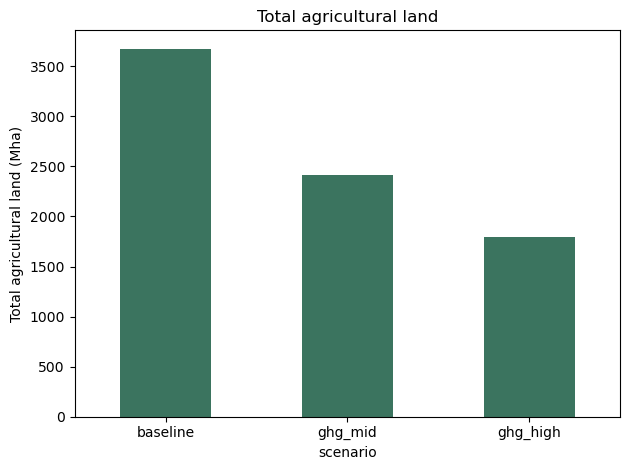

In [2]:
land = load("land_use.parquet")
totals = land.groupby("scenario")["area_mha"].sum().reindex(scenarios)
print(totals.round(1))

ax = totals.plot.bar(ylabel="Total agricultural land (Mha)", rot=0, color="#3b745f")
ax.set_title("Total agricultural land")
plt.tight_layout()

## Grassland area

`land_use.parquet` also covers grazed grassland (crop code `grassland`). Separating it from cropland shows whether the reduction in cropland is offset by more grazing land, or whether both shrink together.

          cropland  grassland
scenario                     
baseline    1359.4     2317.5
ghg_mid      975.0     1435.6
ghg_high     812.5      983.3


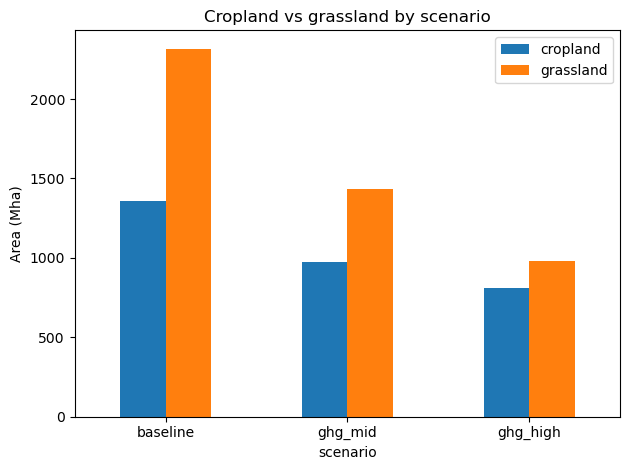

In [3]:
is_grassland = land["crop"] == "grassland"
by_land_type = pd.DataFrame(
    {
        "cropland": land[~is_grassland].groupby("scenario")["area_mha"].sum(),
        "grassland": land[is_grassland].groupby("scenario")["area_mha"].sum(),
    }
).reindex(scenarios)
print(by_land_type.round(1))

ax = by_land_type.plot.bar(ylabel="Area (Mha)", rot=0)
ax.set_title("Cropland vs grassland by scenario")
plt.tight_layout()

## Net GHG emissions by gas

Stacked bars decompose net emissions (in MtCO₂-equivalent) into CO₂, CH₄, and N₂O contributions. As the GHG price rises, the optimiser cuts the cheapest-to-abate emission sources first.

gas          ch4      co2     n2o
scenario                         
baseline  4231.8   -752.6  1777.3
ghg_mid   3781.5 -10841.5  1433.5
ghg_high  3009.1 -12407.4  1174.9


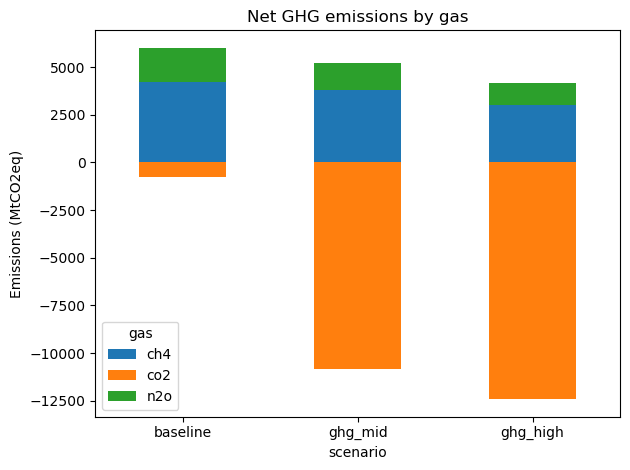

In [4]:
emissions = load("net_emissions.parquet")
by_gas = (
    emissions.groupby(["scenario", "gas"])["mtco2eq"]
    .sum()
    .unstack("gas")
    .reindex(scenarios)
)
print(by_gas.round(1))

ax = by_gas.plot.bar(stacked=True, ylabel="Emissions (MtCO2eq)", rot=0)
ax.set_title("Net GHG emissions by gas")
plt.tight_layout()

## Animal feed composition

`feed_by_category.parquet` breaks down dry-matter feed use (Mt) by category — grass & leaves, grains, oilseed cakes, residues, and so on. Even when total livestock output is fixed (which is roughly the case here, since consumption is fixed), the *mix* of feed that supports it changes as the optimiser substitutes cheap-to-emit feeds for cleaner alternatives.

category  Grass & leaves  Grains  Crop residues  Oilseed cakes  By-products
scenario                                                                   
baseline          3860.9  1206.4          629.7          438.2        284.3
ghg_mid           3524.6  1267.0          611.1          382.9        261.9
ghg_high          2831.9  1323.8          524.0          373.6        134.2


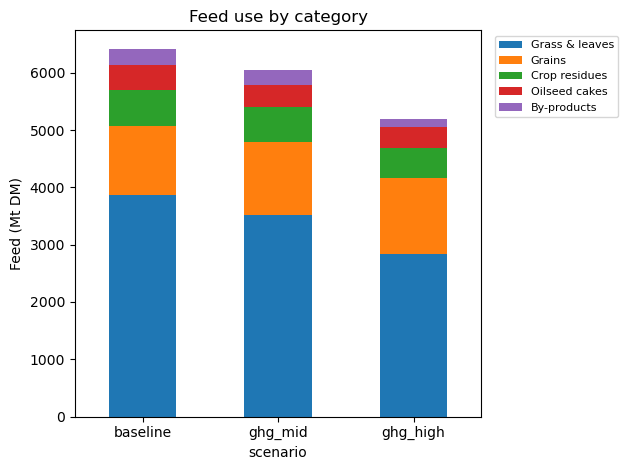

In [5]:
feed = load("feed_by_category.parquet")
by_category = (
    feed.groupby(["scenario", "category"])["mt_dm"]
    .sum()
    .unstack("category")
    .reindex(scenarios)
)
# Order columns by total feed use for a cleaner stacked plot.
by_category = by_category.reindex(
    columns=by_category.sum().sort_values(ascending=False).index
)
print(by_category.round(1))

ax = by_category.plot.bar(stacked=True, ylabel="Feed (Mt DM)", rot=0)
ax.set_title("Feed use by category")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()

## Objective breakdown

Each column is a cost category in billion USD. The `ghg_cost` column only appears in scenarios with a non-zero GHG price, and at these GHG prices it is *negative*: the model achieves net-negative emissions (cropland shrinks and regrowth sequesters carbon), so `ghg_price × net_emissions` is a revenue term that reduces the objective. Production-side categories (`crop_production`, `animal_production`, `trade`, `fertilizer`) shift as the solver reorganises supply under the carbon price. The sum across columns matches the LP's reported objective value (up to the 1% tolerance enforced by the extractor).

In [6]:
breakdown = load("objective_breakdown.parquet").set_index("scenario").reindex(scenarios)
breakdown.round(2).T

scenario,baseline,ghg_mid,ghg_high
category,,,
animal_production,23.82,25.88,29.22
consumption,0.04,0.04,0.04
crop_production,168.55,135.73,145.61
feed_conversion,0.03,0.03,0.03
fertilizer,38.75,21.69,16.43
land_use,0.01,0.30,1.37
processing,0.03,0.03,0.03
trade,48.91,65.09,105.80
production_stability,39.58,273.84,474.14
